# Introduction to NumPy

**NumPy** (Numerical Python) is Python's core library for numerical and scientific computing. It's the foundation that libraries like Pandas, scikit-learn, and TensorFlow are built on top of, and it's the standard way to work efficiently with large datasets, vectors, and matrices.

**Features of NumPy:**
- Provides support for fast, memory-efficient multi-dimensional arrays.
- Offers mathematical and statistical functions for numeric data (sums, means, standard deviations, and more).
- Enables **vectorized operations** — applying a calculation to an entire array at once, without writing a manual loop.
- Powers array **broadcasting**, matrix multiplication, and linear algebra operations used throughout data science and machine learning.

### What You'll Learn

1. **Creating arrays** — 1D, 2D, and beyond, plus their core attributes
2. **Array construction helpers** — zeros, constants, ranges, and random numbers
3. **Combining and comparing arrays** — stacking, intersections, and differences
4. **Math on arrays** — arithmetic, sums, and descriptive statistics
5. **Reshaping and matrix operations** — slicing, transposing, and multiplying
6. **Saving/loading arrays**, plus **visualizing** data with Matplotlib
7. **A mini real-world project**: turning text into numeric vectors for NLP
8. **Broadcasting** — NumPy's rules for combining arrays of different shapes

> **Note:** This notebook is written for you to **run yourself**. The code has been checked for correctness, but no cells have been pre-executed — run each cell in order so the variables build up correctly.

---

# Importing NumPy

To use NumPy in Python, you need to import it first. The convention is to use the alias `np`, which makes it much quicker to call functions from the library (`np.array(...)` instead of `numpy.array(...)`).

In [ ]:
import numpy as np

---
# Creating Arrays in NumPy

An **array** is a grid of values, all of the **same type**, indexed by a tuple of non-negative integers. Arrays in NumPy are created using the `np.array()` function, which can take a Python list (or list of lists) as input.

**Types of Arrays by Dimension:**
1. **0D (scalar):** A single number, with no axes at all.
2. **1D (vector):** A single row of values — similar to a Python list.
3. **2D (matrix):** Rows and columns — like a spreadsheet or a table.
4. **3D and higher (tensor):** A stack of matrices — used for things like image batches (height x width x color channels) or video.

The diagram below previews all four; we'll build up to 2D (and touch 3D in the broadcasting section) over the next few cells.

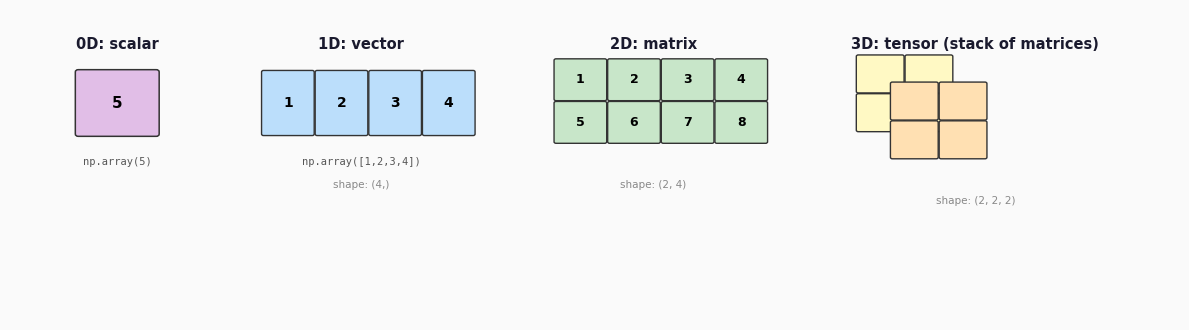

# Single-Dimensional Array

We can create a 1D array from a Python list using `np.array()`. This is the simplest type of array and is used for linear data structures — a list of prices, a list of temperatures, a list of test scores.

In [ ]:
list1 = [1,2,3,4]
n1 = np.array(list1)
n1

array([1, 2, 3, 4])

---
# Attributes of NumPy Arrays

NumPy arrays come with built-in attributes for introspection — quick ways to check what you're working with before you compute anything:
1. `type()`: Identifies the Python object type (should say `numpy.ndarray`).
2. `.dtype`: Displays the data type of the array's *elements* (e.g. `int64`, `float64`).
3. `.shape`: Reveals the structure or dimensions of the array (e.g. rows and columns).

In [ ]:
type(n1)

numpy.ndarray

In [ ]:
n1.dtype

dtype('int64')

In [ ]:
n1.shape

(4,)

---
# Multi-Dimensional Arrays

NumPy supports multi-dimensional arrays (e.g. matrices). These are arrays where each "row" is itself a list. Below we create a 2D array with **two rows and four columns** — you could think of it as two data points, each with four features.

In [ ]:
n2 = np.array([[1,2,3,4],[5,6,7,8]])
n2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [ ]:
type(n2)

numpy.ndarray

In [ ]:
n2.dtype

dtype('int64')

In [ ]:
n2.shape

(2, 4)

### A Note on Mixed Numeric Types

What happens if a 2D array mixes integers and floats?

In [ ]:
n3 = np.array([[1,2,3.1,4]])
n3

array([[1. , 2. , 3.1, 4. ]])

In [ ]:
n3.dtype

dtype('float64')

Notice every value printed with a decimal point (`1.0`, `2.0`, `3.1`, `4.0`), and `.dtype` shows `float64`. NumPy arrays must hold a **single, consistent type** — so when integers and floats are mixed, NumPy silently **upcasts everything to float** so no precision is lost.

---
# Handling Mixed Data Types

If an array contains elements of genuinely different kinds (e.g. numbers and text), NumPy converts everything to a common type — typically a Unicode string (`dtype='<U...'`). This limits which numeric operations you can perform on the array.

In [ ]:
n4 = np.array([1, 2, 3])
n4

array([1, 2, 3])

In [ ]:
n4.dtype

dtype('int64')

In [ ]:
n4*2

array([2, 4, 6])

This is a useful lesson: NumPy is built for **numeric** data. If you need to mix numbers and text meaningfully (like a real dataset with both), reach for **Pandas** instead — its DataFrame allows each *column* to have its own type, unlike a NumPy array which has just one type for the whole array.

---

# Arrays Filled with Zeros

NumPy provides the `np.zeros()` function to create arrays where every element is initialized to `0`. This is useful for creating **placeholder arrays** — for example, allocating space for results you'll fill in later, or building a starting point for one-hot encoded vectors (which we'll do later in this lab).

**Parameters:**
- `shape`: A tuple specifying the dimensions of the array, e.g. `(rows, columns)`.
- `dtype`: The data type of the elements (default is `float`).

In [ ]:
n5 = np.zeros((1,10))
n5

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
n6 = np.zeros((10,1))
n6

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [ ]:
n7 = np.zeros((1,10), dtype = int)
n7

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

Notice `n5` and `n7` look almost the same, but `n5`'s values print as `0.` (float) while `n7`'s print as `0` (integer) — a direct result of the `dtype=int` argument.

---
# Arrays Filled with Constant Values

The `np.full()` function creates an array where every element is set to a specified constant. This is handy for pre-filled arrays you'll modify later, or for representing a "default" value across a grid.

In [ ]:
n8 = np.full((4,5,10,1,12), 4)
n8

array([[[[[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         ...,

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]]],


        [[[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         ...,

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]]],


        [[[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         ...,

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]]],


        [[[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         ...,

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]],

         [[4, 4, 4, ..., 4, 4, 4]]],


        [[[4, 4, 4, ..., 4, 4, 4]],

       

This example has **5 dimensions**! `(4, 5, 10, 1, 12)` means: 4 blocks, each containing 5 blocks, each containing 10 blocks, each containing 1 row, each containing 12 columns — all filled with the value `4`. You won't often need 5D arrays in practice, but this demonstrates that NumPy isn't limited to 1D/2D — `np.full()`, `np.zeros()`, and friends work with any number of dimensions.

---
# Arrays with Ranges

NumPy offers `np.arange()` to generate evenly spaced values within a range — the array equivalent of Python's built-in `range()`.

**Parameters:**
- `start`: The starting value of the sequence.
- `stop`: The end value (**exclusive** — not included in the output).
- `step`: The spacing between values (default is `1`).

In [ ]:
n8 = np.arange(10,21)
n8

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [ ]:
n9 = np.arange(10,21,2)
n9

array([10, 12, 14, 16, 18, 20])

`np.arange(10, 21)` produces every integer from 10 up to (but not including) 21. Adding `step=2` skips every other value, giving you `10, 12, 14, ...`.

> ⚠️ Notice the first cell above **reuses the variable name `n8`**, which was previously the `(4,5,10,1,12)` constant-filled array from the `np.full()` example. This overwrites it! In your own code, prefer giving each array a distinct, descriptive name to avoid this kind of accidental overwrite.

---

# Random Numbers in NumPy

NumPy provides random number generation for both integers and floating-point numbers — essential for simulations, shuffling data, initializing model weights, and generating test data (as we'll do later for our box plots and histograms):

1. `np.random.randint(low, high, size)`: Generates random **integers** in `[low, high)`.
2. `np.random.uniform(low, high, size)`: Generates random **floating-point** numbers in `[low, high)`.

Use `np.round()` to limit the decimal precision of floating-point results.

In [ ]:
n10 = np.random.randint(2,12)
n10

6

In [ ]:
n10 = np.random.randint(2,12, 4)
n10

array([2, 9, 2, 9])

Without a `size` argument, `np.random.randint()` returns a **single** random integer. Passing `size=4` (as the third positional argument above) instead returns an **array** of 4 random integers.

In [ ]:
n11 = np.random.uniform(1.0, 101.0, 7)
n11

array([15.59839857, 75.48875461,  4.80726146, 61.85220291, 75.26091513,
       21.59661977, 34.69136288])

In [ ]:
decimal_limit = 2
n12 = np.random.uniform(1.0, 101.0, 7)
n12_rounded = np.round(n12, decimal_limit)
n12_rounded

array([89.85, 18.49, 98.44, 99.03, 65.55, 29.35, 70.8 ])

`np.round(array, decimals)` rounds every element to the given number of decimal places — much faster than looping over the array and rounding each value with Python's built-in `round()`.

> 💡 **Reproducibility tip:** Every time you run these cells, you'll get *different* random numbers. If you want the *same* "random" numbers every run (useful for debugging or sharing reproducible results), set a seed first: `np.random.seed(42)`. We'll use this later in the visualization section.

---

# Unequal Elements in Sub-Arrays

What happens when the "rows" of a nested list don't all have the same length? NumPy calls this a **ragged** array. Since a true NumPy array requires a fixed, rectangular shape, NumPy falls back to creating an **object array** (`dtype=object`) — where each "row" is actually a separate Python list living inside the array, rather than genuine numeric rows. These behave more like nested Python lists and lose most of NumPy's speed benefits.

In [ ]:
n15 = [[10, 20, 30], [40], [50, 40, 30, 40]]
print(n15)

[[10, 20, 30], [40], [50, 40, 30, 40]]


This is a plain Python list of lists so far — no NumPy involved yet. Notice the inner lists have **3, 1, and 4** elements respectively — there's no shared row length.

In [ ]:
n15 = np.array([[10, 20, 30], [40], [50,40,30,40]], dtype=object)

Passing `dtype=object` explicitly tells NumPy: *"I know these rows are different lengths — don't try to make this rectangular, just store each row as a generic Python object instead."* Without `dtype=object`, modern versions of NumPy will raise an error rather than guess what you meant.

In [ ]:
n15.shape

(3,)

The shape is `(3,)` — NumPy sees this as a 1D array containing **3 objects** (each object happens to be a list), *not* a proper 2D array. If you need genuinely ragged data, it's often cleaner to keep it as a plain Python list of lists (or a Pandas Series) rather than forcing it into a NumPy array.

---

# Stacking Arrays

NumPy provides several functions to **combine** separate arrays into one:
- `np.vstack()`: Stacks arrays **vertically** — adds them as new rows.
- `np.hstack()`: Stacks arrays **horizontally** — joins them end-to-end.
- `np.column_stack()`: Combines 1D arrays **column-wise** into a 2D array.

**Real-world scenario:** Imagine `n16` and `n17` are two separate sensor readings, or two rows of a dataset collected at different times, that you now want to combine into one array.

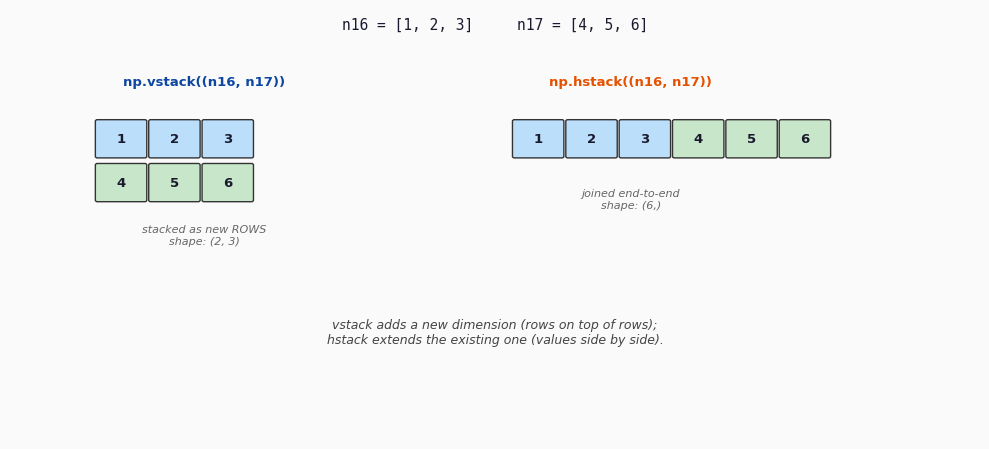

In [ ]:
n16 = np.array([1,2,3])
n17 = np.array([4,5,6])

In [ ]:
# Vertical Stack
np.vstack((n16,n17))

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
# Horizontal Stack
np.hstack((n16,n17))

array([1, 2, 3, 4, 5, 6])

In [ ]:
# Horizontal Stack (order swapped)
np.hstack((n17,n16))

array([4, 5, 6, 1, 2, 3])

Notice that swapping the argument order for `hstack` also swaps the output order — `[4,5,6,1,2,3]` instead of `[1,2,3,4,5,6]`. Order matters!

In [ ]:
# Column Stack
np.column_stack((n16,n17))

array([[1, 4],
       [2, 5],
       [3, 6]])

`np.column_stack()` treats each input 1D array as a **column** rather than a row — the result is a `(3, 2)` matrix, with `n16` forming the first column and `n17` forming the second. This is especially useful when you have several separate feature arrays (e.g. `age`, `income`, `score`) that you want to combine side-by-side into one dataset-like matrix.

---

# Array Intersection and Difference

NumPy provides set-like operations to compare two arrays:
- `np.intersect1d(array1, array2)`: Finds elements that appear in **both** arrays.
- `np.setdiff1d(array1, array2)`: Finds elements in the **first** array that do **not** appear in the second.

**Real-world scenario:** Imagine `n18` is a list of customer IDs who visited your website this week, and `n19` is a list of customer IDs who made a purchase. The intersection tells you who visited *and* purchased; the difference tells you who visited but *didn't* purchase.

In [ ]:
n18 = np.array([1,2,3,4,5])
n19 = np.array([4,5,6,7,8])

In [ ]:
#Intersection Value
np.intersect1d(n18,n19)

array([4, 5])

In [ ]:
#Difference Value (in n18 but not in n19)
np.setdiff1d(n18,n19)

array([1, 2, 3])

In [ ]:
#Difference Value (in n19 but not in n18)
np.setdiff1d(n19,n18)

array([6, 7, 8])

Notice `setdiff1d(n18, n19)` and `setdiff1d(n19, n18)` give **different** results — the function isn't symmetric, so argument order matters. `intersect1d`, on the other hand, gives the same result either way round, since "elements common to both" doesn't depend on order.

---

# NumPy Array Sum

`np.sum()` adds up array values — and with the `axis` parameter, you can control **which direction** the summing happens across a 2D array.

In [ ]:
#Total Sum -- adds every single element across both arrays
n20 = np.array([1,2,3])
n21= np.array([4,5,6])
np.sum([n20,n21])

np.int64(21)

In [ ]:
#Column Sum (axis=0) -- sums DOWN each column, collapsing the rows
np.sum([n20,n21],axis=0)

array([5, 7, 9])

In [ ]:
#Row Sum (axis=1) -- sums ACROSS each row, collapsing the columns
np.sum([n20,n21],axis=1)

array([ 6, 15])

`[n20, n21]` is treated as a 2D array with 2 rows and 3 columns: `[[1,2,3],[4,5,6]]`.

- **No `axis`** → sums **all 6 values** together → `21`.
- **`axis=0`** ("collapse the rows", i.e. go *down* each column) → `[1+4, 2+5, 3+6]` = `[5, 7, 9]`.
- **`axis=1`** ("collapse the columns", i.e. go *across* each row) → `[1+2+3, 4+5+6]` = `[6, 15]`.

> 💡 **Memory trick:** `axis=0` moves down (through rows), `axis=1` moves across (through columns). This same `axis` logic applies to `.mean()`, `.max()`, `.min()`, and most other NumPy reduction functions.

---

# Arithmetic Operations on Arrays

NumPy allows **element-wise** arithmetic operations, making it easy to perform math on an entire array without writing a manual loop:
- Addition: `array + value`
- Subtraction: `array - value`
- Multiplication: `array * value`
- Division: `array / value`

In [ ]:
n22 = np.array([1,2,3])

In [ ]:
#Addition
n22+1

array([2, 3, 4])

In [ ]:
#Subtraction
n22-1

array([0, 1, 2])

In [ ]:
#Multiplication
n22*2

array([2, 4, 6])

In [ ]:
#Division
n23 = n22/2

In [ ]:
n23.dtype

dtype('float64')

Even though `n22` is made of integers, dividing by `2` produces `float64` results (`[0.5, 1., 1.5]`) — division in NumPy (like in Python 3) always returns floats, since integer division would otherwise silently lose the fractional part.

---

# Descriptive Statistics with NumPy

NumPy provides functions to calculate key statistical metrics on an array in one call each — the same summary numbers you'd compute by hand, just instant and vectorized:
- `np.mean(array)`: The **mean** (average) — sum of values divided by count.
- `np.median(array)`: The **middle** value when the array is sorted (robust to outliers, unlike the mean).
- `np.var(array)`: The **variance** — the average squared distance from the mean, measuring spread.
- `np.std(array)`: The **standard deviation** — the square root of variance, in the same units as the original data, making it easier to interpret than variance.

In [ ]:
n24 = np.array([1,2,3,3,45,5,6])

In [ ]:
#Mean
np.mean(n24)

np.float64(9.285714285714286)

In [ ]:
#Median
np.median(n24)

np.float64(3.0)

Notice the mean and median are quite different here — the mean is pulled up by the outlier value `45`, while the median (the middle value once sorted: `1, 2, 3, 3, 5, 6, 45` → middle is `3`) isn't affected by it at all. This is exactly why the median is often preferred for skewed, real-world data (like incomes or house prices).

In [ ]:
#Variance
np.var(n24)

np.float64(215.06122448979593)

In [ ]:
#Standard Deviation
np.std(n24)

np.float64(14.66496588778153)

### Finding the Mode

NumPy itself doesn't have a built-in `mode()` function (the most frequently occurring value) — for that, we borrow one from **SciPy**, a companion scientific-computing library built on top of NumPy.

In [ ]:
#For mode -- need to import it from scipy.stats
from scipy.stats import mode

n25 = np.array([1, 2, 2, 3, 3, 3, 4, 4, 4, 4])
mode_value = mode(n25)
mode_value

ModeResult(mode=np.int64(4), count=np.int64(4))

`mode()` returns an object with two parts: the most frequent value (`mode`) and how many times it occurred (`count`). Here, `4` appears **4 times** — more than any other value — so it's reported as the mode. You can access these individually with `mode_value.mode` and `mode_value.count`.

---

# Transformations of Arrays

NumPy supports advanced transformations for reshaping and manipulating arrays:
- **Slicing**: Extract rows or columns from an array using indexing.
  - `array[start:end]`: Slices **rows**.
  - `array[:, column_index]`: Extracts a specific **column** (the `:` means "all rows").
- **Transpose**: `np.transpose(array)` flips the array so rows become columns and columns become rows.

In [ ]:
n26 = np.array([[10,20,30],[40,50,60],[70,80,90]])
n26

array([[10, 20, 30],
       [40, 50, 60],
       [70, 80, 90]])

In [ ]:
#Extract rows 0 and 1 (row 2 is excluded, since slicing is exclusive of the end)
n26[0:2]

array([[10, 20, 30],
       [40, 50, 60]])

In [ ]:
#Extract column at index 1 (the "middle" column: 20, 50, 80)
n26[:,1]

array([20, 50, 80])

In [ ]:
#Extract the LAST column using negative indexing
n26[:,-1]

array([30, 60, 90])

In [ ]:
np.transpose(n26)

array([[10, 40, 70],
       [20, 50, 80],
       [30, 60, 90]])

`np.transpose(n26)` mirrors the matrix across its diagonal: the first **row** of the original (`[10,20,30]`) becomes the first **column** of the result. Transposing is used constantly in linear algebra and machine learning — for example, to line up matrix dimensions correctly before multiplication, as we'll see next.

---
# Matrix (Array) Multiplication

Matrix multiplication is performed with `.dot()` or the `@` operator — **not** the same as element-wise `*` multiplication. Two key rules:
- The number of **columns** in the first matrix must match the number of **rows** in the second.
- The resulting matrix has shape `(rows of first matrix, columns of second matrix)`.

In [ ]:
n27 = np.array([[1,2,3],[4,5,6],[7,8,9]])
n27

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
n28 = np.array([[10,11],[12,13],[14,15]])
n28

array([[10, 11],
       [12, 13],
       [14, 15]])

`n27` has shape `(3, 3)` and `n28` has shape `(3, 2)`. Since `n27`'s column count (3) matches `n28`'s row count (3), they can be multiplied — and the result will have shape `(3, 2)`.

In [ ]:
n27.dot(n28)

array([[ 76,  82],
       [184, 199],
       [292, 316]])

In [ ]:
n28.T.dot(n27)  # Transpose n28 (making it shape (2,3)) before multiplying by n27 (shape (3,3))

array([[156, 192, 228],
       [168, 207, 246]])

`n28.T` is shorthand for `np.transpose(n28)` — flipping `n28` from `(3, 2)` to `(2, 3)` so its column count (3) now matches `n27`'s row count (3), making this second multiplication valid too (result shape: `(2, 3)`).

---

# Saving and Loading Arrays

NumPy provides functions to save arrays to disk and reload them later — much faster than re-generating data or re-parsing a CSV every time:
- `np.save(filename, array)`: Saves the array to a binary `.npy` file.
- `np.load(filename)`: Loads a previously saved array back into memory.

In [ ]:
n29 = np.array([1,2,3])
n29

array([1, 2, 3])

In [ ]:
np.save('my_1st_numpy',n29)

In [ ]:
np.load('my_1st_numpy.npy')

array([1, 2, 3])

Running these two cells creates a file called `my_1st_numpy.npy` in your working directory, then reads it straight back into an identical array. The `.npy` format preserves the array's shape and dtype exactly — unlike a plain text or CSV file, there's no re-parsing involved.

---

# Visualizing NumPy Data with Matplotlib

Numbers in an array are hard to interpret at a glance — visualizing them makes patterns, spread, and outliers immediately obvious. The next few sections pair NumPy's random-data generators with Matplotlib's plotting functions.

# Box Plot Visualization

A **box plot** summarizes the distribution of data at a glance:
- The box spans the **interquartile range** (25th to 75th percentile).
- The line inside the box is the **median**.
- The "whiskers" extend to the typical min/max range, and individual points beyond them are flagged as potential **outliers**.

[37 12 72  9 75  5 79 64 16  1] [76 71  6 25 50 20 18 84 11 28 29 14 50 68 87 87 94 96 86 13] [ 9  7 63 61 22 57  1  0 60 81  8 88 13 47 72 30 71  3 70 21 49 57  3 68
 24 43 76 26 52 80]


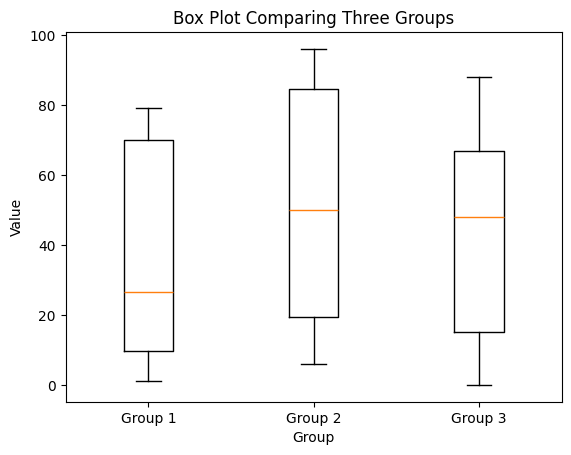

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for three groups
np.random.seed(1)
data1 = np.random.randint(0, 100, 10)
data2 = np.random.randint(0, 100, 20)
data3 = np.random.randint(0, 100, 30)

print(data1, data2, data3)

# Combine the data into a list
data = [data1, data2, data3]

# Create the box plot
plt.boxplot(data, tick_labels=['Group 1', 'Group 2', 'Group 3'])

# Add labels and title
plt.xlabel('Group')
plt.ylabel('Value')
plt.title('Box Plot Comparing Three Groups')

# Show the plot
plt.show()

`np.random.seed(1)` fixes the random number generator so you get the **same** "random" data every time you run this cell — useful for reproducible examples and comparing results with a classmate or colleague. Each of the three groups has a **different sample size** (10, 20, 30) — box plots handle that gracefully, since each box is computed independently from its own group's data.

---

# Histogram Visualization

A **histogram** represents the frequency distribution of data:
- Divides the data into intervals (**bins**).
- Plots the number of occurrences within each bin as a bar.
- Use `plt.hist()`'s `bins` parameter to customize the bin edges.

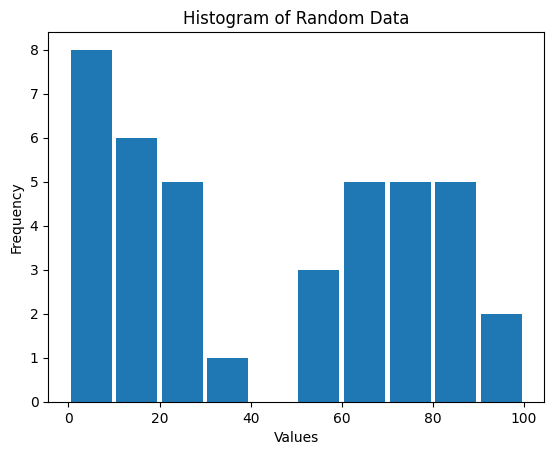

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(1)
data = np.random.randint(0, 100, 40)

# Create the histogram
plt.hist(data, bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], rwidth=0.9)

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Random Data')

# Show the plot
plt.show()

The `bins` list `[0, 10, 20, ..., 100]` defines 10 equal-width buckets. `rwidth=0.9` shrinks each bar slightly (to 90% of the available width) so you can see a thin gap between neighboring bars, making the histogram easier to read.

---

# Scatter Plot Visualization

A **scatter plot** visualizes the relationship between two sets of data:
- Each point represents one `(x, y)` pair.
- Useful for spotting patterns, trends, clusters, or correlations between two numeric variables.

**Key Parameters:**
- `x`: Data for the x-axis.
- `y`: Data for the y-axis.
- `color`: Optional — specifies point color.

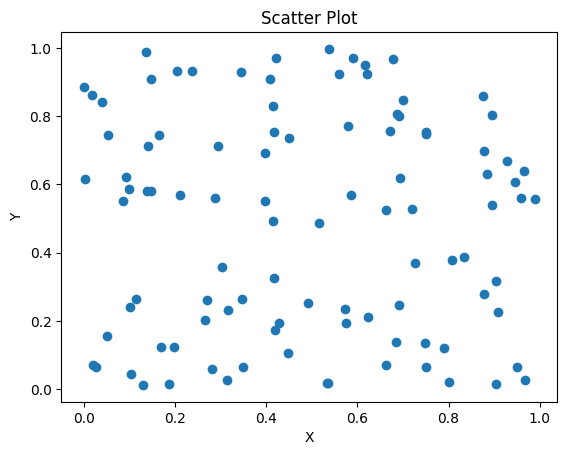

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(1)
x = np.random.random(100)  # Random x values
y = np.random.random(100)  # Random y values

# Plot the scatter plot
plt.scatter(x, y)

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot')

# Show the plot
plt.show()

Since `x` and `y` here are both **independent** random values (with no relationship built in), the points should look like a random, evenly-spread cloud with no visible pattern — that absence of pattern is itself meaningful, and is exactly what you'd expect to see if two real-world variables were genuinely unrelated.

---

# Pie Chart Visualization

A **pie chart** is a circular chart divided into slices to illustrate proportions of a whole. Each slice represents one category's share of the total.

**Key Components in the Code:**
1. **Labels**: The names of the categories (e.g., Apples, Bananas).
2. **Sizes**: The numeric values representing each category's share.
3. **`explode`**: How far a slice is "pulled out" from the pie — `0.1` nudges a slice outward to draw attention to it, `0` keeps it flush with the rest.
4. **`autopct`**: A format string controlling how percentages are displayed on each slice.

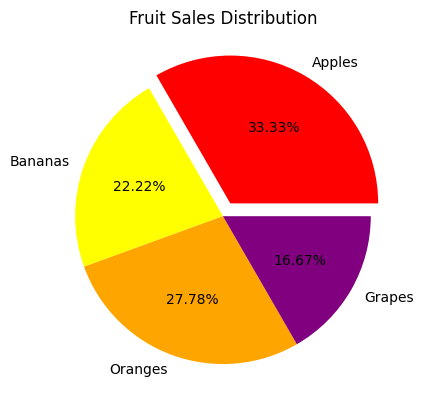

In [ ]:
import matplotlib.pyplot as plt

# Define data for the pie chart
labels = ['Apples', 'Bananas', 'Oranges', 'Grapes']
sizes = [30, 20, 25, 15]
colors = ['red', 'yellow', 'orange', 'purple']
explode = (0.1, 0, 0, 0)  # Explode the first slice (Apples)

# Create the pie chart
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%.2f%%')

# Add a title
plt.title('Fruit Sales Distribution')

# Show the plot
plt.show()

`autopct='%.2f%%'` formats each slice's percentage to 2 decimal places (e.g. `30.00%`). The double `%%` is needed because `%` is a special formatting character in Python — `%%` is how you print a **literal** percent sign. Notice the `sizes` list `[30, 20, 25, 15]` sums to 90, not 100 — that's fine, `plt.pie()` automatically normalizes the values into proportions of whatever they sum to.

---

# A Mini Real-World Project: From Text to Numbers

Just like the string-vs-number issue we saw earlier (`n4`), machine learning models can't work with raw text either — everything needs to become numbers first. The rest of this lab builds up, step by step, exactly how that's done in practice: from a simple word list, to one-hot encoded vectors, to full-blown document similarity using real NLP tooling.

# Creating a Vocabulary from Text Data

This first step processes textual data to build a **vocabulary** — the set of all distinct words present in the dataset. Every later encoding technique starts from this vocabulary.

**Step-by-Step:**
1. **Text data**: a list of words (here, fruit names) standing in for words extracted from real documents.
2. **`set(text_data)`**: collapses the list down to only its **unique** words, discarding duplicates.
3. **`sorted(...)`**: puts the unique words in a consistent, predictable order — important, since we'll use each word's *position* in this list as its numeric code.

In [ ]:
import numpy as np

# Example textual data
text_data = ['apple', 'banana', 'orange', 'apple', 'grape']

# Create a vocabulary of unique words
vocab = sorted(set(text_data))
print(vocab)

['apple', 'banana', 'grape', 'orange']


---
# One-Hot Encoding of Words

Just like we one-hot encoded categorical columns in a pandas lab, we can do the same for **words**: each unique word in the vocabulary gets its own column, and each document (here, a single word) gets a `1` in the column matching its word and `0` everywhere else.

In [ ]:
# Create an empty matrix to hold the one-hot encoded vectors:
# one row per item in text_data, one column per unique word in vocab
one_hot_matrix = np.zeros((len(text_data), len(vocab)))
one_hot_matrix

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
# Perform one-hot encoding
for i, word in enumerate(text_data):
    word_index = vocab.index(word)
    one_hot_matrix[i, word_index] = 1

print(one_hot_matrix)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


For each word in `text_data`, we look up **where** it sits in the sorted `vocab` list (`vocab.index(word)`), then flip that one position to `1` in that word's row. Notice the two `'apple'` entries (positions 0 and 3 in `text_data`) produce **identical** rows in the matrix — one-hot encoding always maps the same word to the same vector.

> ⚠️ **A limitation to notice:** one-hot vectors treat every word as equally "different" from every other word — there's no sense that `'orange'` (the fruit) might be conceptually closer to `'apple'` than to, say, an unrelated word like `'car'`. **Word embeddings** (next) fix exactly this.

---
# Word Embeddings

Unlike one-hot encoding, **word embeddings** represent each word as a **dense vector of real numbers**, learned (in real systems) so that words with similar meanings end up with similar vectors. Here we simulate that with a small, hand-picked dictionary standing in for a real pre-trained embedding model.

In [ ]:
import numpy as np

# Example textual data
text_data = ['apple', 'banana', 'orange', 'apple', 'grape']

# Pre-trained word embeddings (example -- in practice these come from a model
# like Word2Vec or GloVe, trained on billions of words)
word_embeddings = {
    'apple': np.array([0.5, 0.3, 0.8]),
    'banana': np.array([0.9, 0.2, 0.4]),
    'orange': np.array([0.7, 0.6, 0.1]),
    'grape': np.array([0.2, 0.4, 0.6])
}

# Convert text data to its embedding vectors by looking each word up in the dictionary
embedded_vectors = np.array([word_embeddings[word] for word in text_data])
print("Embedded vectors:\n", embedded_vectors)

Embedded vectors:
 [[0.5 0.3 0.8]
 [0.9 0.2 0.4]
 [0.7 0.6 0.1]
 [0.5 0.3 0.8]
 [0.2 0.4 0.6]]


Each word is now a **3-number vector** instead of a single `0`/`1` flag — far more compact than one-hot encoding would be for a large vocabulary, and (in a real, trained embedding) these numbers would capture something about each word's *meaning*.

A common next step is to **average** the vectors of all words in a sentence or document, producing one vector that represents the whole piece of text:

In [ ]:
# Average the word vectors to get one vector representing the whole list of words
document_vector = embedded_vectors.mean(axis=0)
print("Averaged document vector:", document_vector)

Averaged document vector: [0.56 0.36 0.54]


`axis=0` (as we saw in the Sum section) averages **down each column** — giving one value per embedding dimension, averaged across all 5 words. This simple "average the word vectors" trick is a surprisingly strong baseline for representing a sentence numerically, and is a stepping stone toward the more sophisticated document vectors used in the next section.

---

# Real Documents: Turning Text into Vectors at Scale

The dictionary-based embedding above was hand-built for 4 fruit words — for real text, we need tools that can learn a vocabulary and build vectors automatically from thousands of documents. This section uses `scikit-learn`'s text tools together with NumPy to do exactly that, using a real, well-known collection of newsgroup posts.

# Importing Libraries

This imports everything needed for the rest of this section:
- `fetch_20newsgroups`: loads a classic, freely available NLP dataset (posts from old Usenet newsgroups).
- `CountVectorizer` / `TfidfVectorizer`: convert raw text into numeric vectors, using two different strategies (explained below).

In [ ]:
#import libraries
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Step 1: Loading the Dataset

`fetch_20newsgroups` downloads (and locally caches) a collection of newsgroup posts, commonly used as a benchmark for text classification and NLP. We restrict it to two topics — `sci.space` and `comp.graphics` — and keep only the first 10 documents, to keep the output small and easy to read.

> **Note:** This cell needs an internet connection the first time it's run, since it downloads the dataset. After that, it's cached locally and loads instantly.

In [ ]:
# Step 1: Load the dataset
newsgroups = fetch_20newsgroups(subset='train', categories=['sci.space', 'comp.graphics'], shuffle=True, random_state=42)
texts = newsgroups.data[:10]  # Use a small subset for simplicity -- documents 0 through 9 (10 total)

In [ ]:
texts[0] #checking the first document

'From: ab@nova.cc.purdue.edu (Allen B)\nSubject: Re: thining algorithm\nOrganization: Purdue University\nLines: 15\n\nIn article <1q7615INNmi@shelley.u.washington.edu> kshin@stein.u.washington.edu  \n(Kevin Shin) writes:\n> I am trying obtain program to preprocess handwriting characters.\n> Like thining algorithm, graph alogrithm.\n> Do anyone know where I can obtain those?\n\nI usually use "Algorithms for graphics and image processing" by\nTheodosios Pavlidis, but other people here got them same idea and now\n3 of 4 copies in the libraries have been stolen!\n\nAnother reference is "Digital Image Processing" by Gonzalez and\nWintz/Wood, which is widely available but a little expensive ($55\nhere- I just checked today).\n\nab\n'

# Printing All Documents Cleanly

Raw newsgroup posts include headers, line breaks, and inconsistent formatting. This loop prints each of the 10 documents with a clear "Document N" label and a separator line, making it much easier to skim through the corpus and understand what we're about to vectorize.

In [ ]:
# Printing all the documents cleanly
for i, doc in enumerate(texts[:10]):
    print(f"Document {i+1}:")
    print(doc)
    print("\n" + "-"*50 + "\n")  # Separator line for better readability

Document 1:
From: ab@nova.cc.purdue.edu (Allen B)
Subject: Re: thining algorithm
Organization: Purdue University
Lines: 15

In article <1q7615INNmi@shelley.u.washington.edu> kshin@stein.u.washington.edu  
(Kevin Shin) writes:
> I am trying obtain program to preprocess handwriting characters.
> Like thining algorithm, graph alogrithm.
> Do anyone know where I can obtain those?

I usually use "Algorithms for graphics and image processing" by
Theodosios Pavlidis, but other people here got them same idea and now
3 of 4 copies in the libraries have been stolen!

Another reference is "Digital Image Processing" by Gonzalez and
Wintz/Wood, which is widely available but a little expensive ($55
here- I just checked today).

ab


--------------------------------------------------

Document 2:
From: stephens@geod.emr.ca (Dave Stephenson)
Subject: Re: Clementine Science Team Selected
Nntp-Posting-Host: ngis.geod.emr.ca
Organization: Dept. of Energy, Mines, and Resources, Ottawa
Lines: 32

nickh@CS.

`stop_words='english'` removes extremely common words (`"the"`, `"is"`, `"and"`, ...) that carry little meaning on their own. `max_features=100` keeps only the 100 most frequent remaining words across the corpus, so `count_array` has shape `(10, ≤100)` — one row per document, one column per kept word, with each cell holding a word count.

# Step 3: Converting Text to Vectors Using TF-IDF Vectorizer

`TfidfVectorizer` improves on plain word counts using **TF-IDF** (Term Frequency–Inverse Document Frequency) — a score that weighs a word by how often it appears in a document, *discounted* by how common that word is across the whole corpus. The intuition: a word that appears often in one document but rarely elsewhere is more informative than a word that appears constantly everywhere.

In [ ]:
# Step 3: Convert text to vectors using TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

# Convert to NumPy array
tfidf_array = tfidf_matrix.toarray()
print("TF-IDF Vectorizer Output:")
print(tfidf_array)

TF-IDF Vectorizer Output:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.12298249 0.         0.         0.
  0.         0.         0.         0.         0.         0.21447211
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.33598784 0.         0.
  0.         0.         0.         0.         0.         0.
  0.18763775 0.         0.         0.         0.         0.14981685
  0.         0.         0.16682341 0.09327782 0.         0.
  0.         0.         0.         0.         0.         0.
  0.10216815 0.18763775 0.         0.         0.         0.21447211
  0.50458603 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.09327782
  0.         0.         0.         0.         0.         0.
  0.         0.12298249 0.21447211 0.         0.21447211 0.
  0.         0.         0.         0.50458

Unlike the CountVectorizer's raw integer counts, TF-IDF values are **decimals** — words that are frequent *within* a document but rare *across* the corpus get higher scores, while words common to every document (even after removing stop words) get scores pulled toward zero.

---

# Performing Document Similarity Calculations and Normalization

Now we bring NumPy back in directly. This step calculates how similar each pair of documents is (using the **dot product**) and demonstrates **L2 normalization** — both foundational NumPy operations used throughout text similarity and NLP tasks.

In [ ]:
# Step 4: Perform NumPy operations
# Calculate document similarity using the dot product
similarity = np.dot(tfidf_array, tfidf_array.T)
print("Document Similarity Matrix:")
print(similarity)

# Normalize the vectors (L2 normalization)
norms = np.linalg.norm(tfidf_array, axis=1, keepdims=True)
normalized_vectors = tfidf_array / norms
print("\nL2 Normalized Vectors:")
print(normalized_vectors)

Document Similarity Matrix:
[[1.         0.03762933 0.03228363 0.07665539 0.16795389 0.02444424
  0.16332718 0.09734422 0.11044125 0.13996117]
 [0.03762933 1.         0.10082164 0.05759693 0.05960184 0.00822824
  0.02667333 0.0415354  0.09746221 0.08127635]
 [0.03228363 0.10082164 1.         0.03070602 0.04583447 0.02642574
  0.02342747 0.02274272 0.08897615 0.08822783]
 [0.07665539 0.05759693 0.03070602 1.         0.04291494 0.01752901
  0.06514112 0.11278062 0.04008249 0.02190929]
 [0.16795389 0.05960184 0.04583447 0.04291494 1.         0.01336573
  0.07410716 0.11829614 0.07885674 0.03951964]
 [0.02444424 0.00822824 0.02642574 0.01752901 0.01336573 1.
  0.02445168 0.01880657 0.04944268 0.02927799]
 [0.16332718 0.02667333 0.02342747 0.06514112 0.07410716 0.02445168
  1.         0.08209315 0.07819961 0.04179018]
 [0.09734422 0.0415354  0.02274272 0.11278062 0.11829614 0.01880657
  0.08209315 1.         0.04541595 0.04307831]
 [0.11044125 0.09746221 0.08897615 0.04008249 0.07885674 0.0

**Explanation:**

- `np.dot(tfidf_array, tfidf_array.T)` multiplies the TF-IDF matrix by its own transpose. The result is a **10x10 matrix** where entry `(i, j)` measures how similar document `i` is to document `j` — the diagonal will be each document's similarity to *itself* (the highest value in its row).
- `np.linalg.norm(tfidf_array, axis=1, keepdims=True)` computes the **length** (L2 norm) of each document's vector. `keepdims=True` keeps the result as a column of shape `(10, 1)` instead of flattening it to `(10,)`, which is exactly what allows the next line's division to **broadcast** correctly against `tfidf_array`'s shape `(10, 100)` — the same broadcasting rules from earlier in this lab.
- Dividing each vector by its own length rescales every document vector to have length exactly `1`, which is what makes **cosine similarity** (used below) meaningful — it isolates the *direction* of each vector (what the document is "about") from its raw *magnitude* (how long the document is).

---
# Visualizing the Similarity Matrix as a Heatmap

A **heatmap** turns the `similarity` matrix's numbers into colors, making it far easier to spot which documents are most alike at a glance than scanning a grid of numbers.

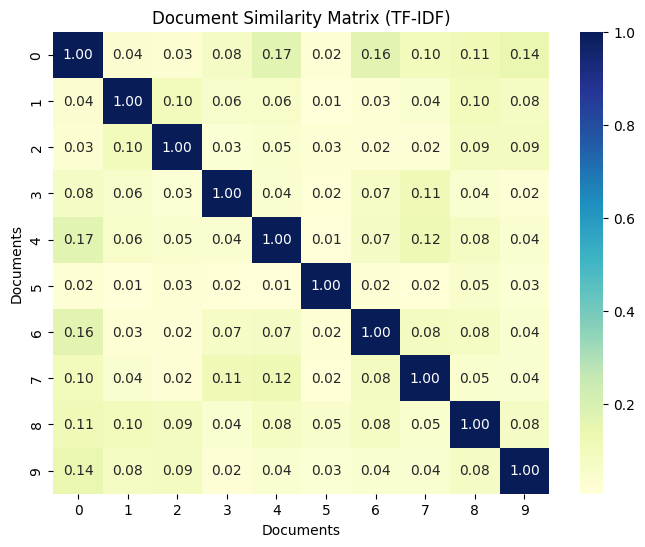

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 5: Plot similarity matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(similarity, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True)
plt.title("Document Similarity Matrix (TF-IDF)")
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.show()

`annot=True` prints each cell's numeric value directly on top of its color, `cmap='YlGnBu'` sets a yellow-green-blue color scale (darker = higher similarity), and `fmt='.2f'` formats the annotations to 2 decimal places. You should see a bright diagonal (every document is maximally similar to itself) with varying shades elsewhere depending on topic overlap.

---

# Evaluating Similarity Between a Query Document and a Corpus

Often you don't want to compare documents *within* a fixed corpus — you want to check how similar a **brand-new query document** is to an existing corpus (exactly what a search engine or a "find similar articles" feature does). This function wraps that up: it combines the query with the corpus, re-vectorizes everything together, and returns how similar the query is to each original document.

**Why re-vectorize instead of reusing `tfidf_matrix` from Step 3?** `tfidf_matrix` was built only from the original 10 documents — the new `query_document`'s words might not even exist in that vocabulary. Fitting a fresh `TfidfVectorizer` on `corpus + [query_document]` together ensures the query's vocabulary is properly represented.

In [ ]:
# Function to evaluate similarity between a new query document and an existing corpus
def evaluate_similarity(query_document, corpus):
    # Combine the query document with the corpus so both get vectorized together
    documents = corpus + [query_document]

    # Vectorize all documents (corpus + query) using TF-IDF
    vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
    tfidf = vectorizer.fit_transform(documents)

    # The query document is the LAST row -- compare it against every corpus
    # document (all rows except the last) using cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarities = cosine_similarity(tfidf[-1], tfidf[:-1])
    return similarities

# Pass your query document to the function
query_document = "NASA is working on developing new technologies for space exploration."
similarity_scores = evaluate_similarity(query_document, texts)
print("Similarity between the query document and each document in the corpus:")
print(similarity_scores)

Similarity between the query document and each document in the corpus:
[[0.         0.         0.         0.27976703 0.         0.
  0.         0.14770584 0.         0.        ]]


**Explanation:**

- `corpus + [query_document]` uses Python list concatenation to add the query as an 11th "document" — `texts` is a list of 10 strings, so wrapping `query_document` in `[ ]` lets us append it the same way.
- `tfidf[-1]` (the last row) is the query's own vector; `tfidf[:-1]` (every row except the last) is the original 10 documents.
- `cosine_similarity()` (from `sklearn.metrics.pairwise`) measures the angle between vectors rather than their raw dot product — it returns a value between `0` (completely unrelated) and `1` (identical direction), regardless of document length.
- The function **returns** the similarity scores (fixing the original version, which computed `documents` but never actually vectorized or compared anything) — now the caller can actually use the result, as shown above.

---
# Cosine Similarity Between Documents — Manual Walkthrough

Let's unpack exactly what happened inside `evaluate_similarity()` above, one step at a time — useful both as a sanity check and to see the mechanics behind the abstraction.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Re-vectorize the query together with the corpus, just like evaluate_similarity() does
# internally (tfidf_matrix from Step 3 does NOT include the query, so we can't reuse it)
documents_with_query = texts + [query_document]
tfidf_vectorizer_q = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_with_query = tfidf_vectorizer_q.fit_transform(documents_with_query)

# Compute cosine similarity between the query (last row) and each original document
cosine_similarities = cosine_similarity(tfidf_with_query[-1], tfidf_with_query[:-1])

# Display the similarity results
print("Similarity between the query document and each document in the corpus:")
for i, score in enumerate(cosine_similarities[0]):
    print(f"Document {i+1}: {score:.4f}")

Similarity between the query document and each document in the corpus:
Document 1: 0.0000
Document 2: 0.0000
Document 3: 0.0000
Document 4: 0.2798
Document 5: 0.0000
Document 6: 0.0000
Document 7: 0.0000
Document 8: 0.1477
Document 9: 0.0000
Document 10: 0.0000


This should produce the **same** scores as `evaluate_similarity()` did — because it's doing exactly the same steps by hand. `cosine_similarities[0]` unwraps the single row of results (since we compared just one query against many documents) into a plain 1D array we can loop over with `enumerate()`, printing each document's score to 4 decimal places.

---

# Broadcasting in NumPy

**Broadcasting** is the set of rules NumPy uses to perform element-wise operations on arrays of **different shapes**, without you having to manually resize or copy data. We already relied on it earlier (dividing `tfidf_array` by `norms`, and even the very first `n22 + 1`) — this section makes the rules explicit.

The diagram below shows the two simplest, most common cases: adding a single number to a whole array, and adding a 1D array to a 2D array.

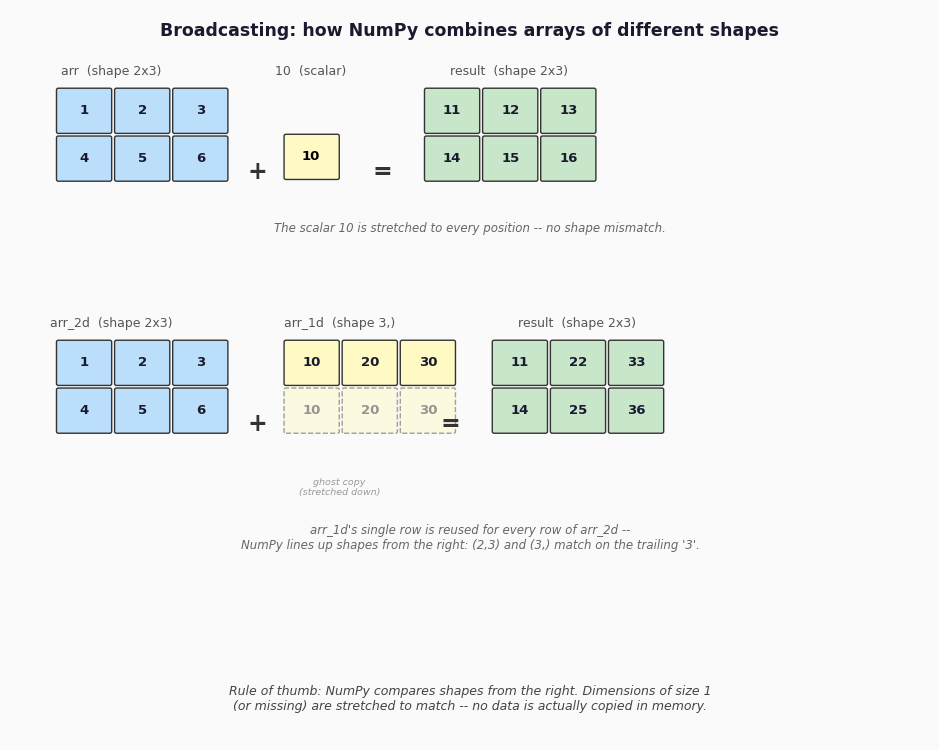

### Scalar Broadcasting

In this example, we add a scalar (a single value) to every element of a 2D array — the simplest and most intuitive form of broadcasting.

In [ ]:
import numpy as np

# Scalar addition
arr = np.array([[1, 2, 3], [4, 5, 6]])
scalar = 10
result = arr + scalar  # Add scalar to each element
print("Scalar Broadcasting:\n", result)

Scalar Broadcasting:
 [[11 12 13]
 [14 15 16]]


### Broadcasting a 1D Array Against a 2D Array

Now let's add a 1D array to a 2D array — a shape combination that comes up constantly in real code (e.g. subtracting a per-column mean, or adding a per-feature bias term).

In [ ]:
# 1D array added to 2D array
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])
arr_1d = np.array([10, 20, 30])
result = arr_2d + arr_1d  # Adds corresponding elements row-wise
print("Broadcasting with Different Shapes:\n", result)

Broadcasting with Different Shapes:
 [[11 22 33]
 [14 25 36]]


### Broadcasting Between 3D and 2D Arrays

Broadcasting extends naturally to higher dimensions too — NumPy automatically expands the smaller array to match the larger array's shape, one dimension at a time, working from the **rightmost** dimension inward.

In [ ]:
# 3D array and 2D array broadcasting
arr_3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr_2d = np.array([[10, 20, 30], [40, 50, 60]])

result = arr_3d + arr_2d  # Adds the 2D array to each "layer" of the 3D array
print("3D and 2D Broadcasting:\n", result)

3D and 2D Broadcasting:
 [[[11 22 33]
  [44 55 66]]

 [[17 28 39]
  [50 61 72]]]


`arr_3d` has shape `(2, 2, 3)` — think of it as **2 layers**, each a `(2, 3)` matrix. `arr_2d` has shape `(2, 3)`, matching each individual layer exactly, so it gets broadcast (repeated) across **both** layers of `arr_3d`.

### Column-wise Broadcasted Operations

A very common real pattern: compute a summary statistic per column, then broadcast it back across every row — for example, subtracting each column's total from every value in that column.

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

# Column-wise sum (broadcasted across rows)
col_sum = arr.sum(axis=0)
print("Column-wise Sum:\n", col_sum)

# Broadcast subtraction
result = arr - col_sum
print("Broadcasted Subtraction:\n", result)

Column-wise Sum:
 [5 7 9]
Broadcasted Subtraction:
 [[-4 -5 -6]
 [-1 -2 -3]]


`col_sum` has shape `(3,)` — one total per column (`1+4=5`, `2+5=7`, `3+6=9`). Subtracting it from `arr` (shape `(2,3)`) broadcasts that single row of column sums across **both** rows, matching the exact 1D-into-2D pattern from the diagram above. This "compute per-column stat, then broadcast back" pattern is exactly how the `StandardScaler` in a typical preprocessing pipeline works internally — subtracting each column's mean from every value in that column.

---

## Summary Cheat Sheet

| Task | Function(s) |
|---|---|
| Create an array | `np.array(list)` |
| Inspect an array | `type()`, `.dtype`, `.shape` |
| Zeros / constants / ranges | `np.zeros(shape)`, `np.full(shape, value)`, `np.arange(start, stop, step)` |
| Random numbers | `np.random.randint(low, high, size)`, `np.random.uniform(low, high, size)`, `np.round()` |
| Combine arrays | `np.vstack()`, `np.hstack()`, `np.column_stack()` |
| Compare arrays | `np.intersect1d()`, `np.setdiff1d()` |
| Sum with direction | `np.sum(arr, axis=0 or 1)` |
| Element-wise math | `+`, `-`, `*`, `/` |
| Descriptive stats | `np.mean()`, `np.median()`, `np.var()`, `np.std()`, `scipy.stats.mode()` |
| Slice / reorganize | `arr[start:end]`, `arr[:, col]`, `np.transpose(arr)` / `.T` |
| Matrix multiply | `.dot()`, `@` |
| Save / load | `np.save()`, `np.load()` |
| Combine different shapes | **Broadcasting** — smaller array is stretched to match, from the right |

---

